# Chen 2004 – NNSE Neutral-Set Sampling

Uses the Chen 2004 budding yeast cell-cycle model (output: CLB2).  
Model setup via `wsbw_pipeline.py`; NNSE core functions from `wsbw_nnse.py`.  
Bin thresholds: logspace + extra lower bins (Tyson-style).  
Plots saved to `../plots/ChenNNSE/`, results to `../results/nnse/`.

In [46]:
%matplotlib inline

import math
import os
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))

from wsbw_pipeline import SPECS, prepare_models
from wsbw_nnse import objective_factory, fill_initial_population, nnse_step

# Suppress RoadRunner/CVODES solver noise
import roadrunner
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_FATAL)

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
LOAD = True   # True → load most recent saved run; False → run simulation from scratch

MODEL_KEY        = "chen2004"
SIGMA            = 0.001   # small: 136-param ODE is very sensitive; large sigma → almost all mutations rejected
MAX_STEPS        = int(5e5)
STABILIZATION    = int(5e4)
BURN_IN_FALLBACK = MAX_STEPS // 2
SEED             = 42

MAX_VALUE     = 250.0
N_BASE        = 30
N_EXTRA       = 0
N_NEUTRAL_BIN = 8       # bins 0 … N_NEUTRAL_BIN are collected as neutral

base           = np.logspace(np.log10(0.1), np.log10(MAX_VALUE), N_BASE + 1)
ratio          = base[1] / base[0]
extra_low      = base[0] / (ratio ** np.arange(N_EXTRA, 0, -1))
bin_thresholds = np.concatenate([extra_low, base])
bin_thresholds[-1] = 1000.0
N_VEC      = len(bin_thresholds)
MIN_FILLED = N_VEC - 2

PLOT_DIR   = ROOT / "plots" / "ChenNNSE"
RESULT_DIR = ROOT / "results" / "nnse"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"LOAD = {LOAD}")
print(f"Bins : {N_VEC}  ({bin_thresholds[0]:.3e} … {bin_thresholds[-1]:.3e})")
print(f"Neutral threshold : f ≤ {bin_thresholds[N_NEUTRAL_BIN]:.4f}  (bins 0–{N_NEUTRAL_BIN})")
print(f"Effective param step : ~{SIGMA * np.sqrt(len(p0) if 'p0' in dir() else 136) * 2:.1%} total")

In [48]:
# ── Model setup ───────────────────────────────────────────────────────────────
audit      = prepare_models()
spec       = next(s for s in SPECS if s.key == MODEL_KEY)
objective, p0, param_names, reference = objective_factory(spec, audit[MODEL_KEY])
t_ref = reference["time"]
y_ref = reference["signal"]

print(f"Model      : {spec.label}")
print(f"Output     : {spec.output}")
print(f"Parameters : {len(param_names)}")
print(param_names)

Model      : Chen 2004
Output     : CLB2
Parameters : 136
['b0', 'bub2h', 'bub2l', 'C0', 'Dn3', 'ebudb5', 'ebudn2', 'ebudn3', 'ec1b2', 'ec1b5', 'ec1k2', 'ec1n2', 'ec1n3', 'ef6b2', 'ef6b5', 'ef6k2', 'ef6n2', 'ef6n3', 'eicdhb2', 'eicdhb5', 'eicdhn2', 'eicdhn3', 'eorib2', 'eorib5', 'esbfb5', 'esbfn2', 'esbfn3', 'J20ppx', 'Jacdh', 'Jaiep', 'Jamcm', 'Jasbf', 'Jatem', 'Jd2c1', 'Jd2f6', 'Jicdh', 'Jiiep', 'Jimcm', 'Jisbf', 'Jitem', 'Jn3', 'Jpds', 'Jspn', 'ka15_p', 'ka15_p_p', 'ka15p', 'ka20_p', 'ka20_p_p', 'kacdh_p', 'kacdh_p_p', 'kaiep', 'kamcm', 'kasb2', 'kasb5', 'kasbf', 'kasesp', 'kasf2', 'kasf5', 'kasrent', 'kasrentp', 'kaswi', 'kd14', 'kd1c1', 'kd1f6', 'kd1pds_p', 'kd20', 'kd2c1', 'kd2f6', 'kd2pds_p_p', 'kd3c1', 'kd3f6', 'kd3pds_p_p', 'kdb2_p', 'kdb2_p_p', 'kdb2p', 'kdb5_p', 'kdb5_p_p', 'kdbud', 'kdcdh', 'kdib2', 'kdib5', 'kdiesp', 'kdif2', 'kdif5', 'kdirentp', 'kdn2', 'kdnet', 'kdori', 'kdppx_p', 'kdppx_p_p', 'kdspn', 'kdswi', 'KEZ', 'KEZ2', 'ki15', 'kicdh_p', 'kicdh_p_p', 'kiiep', 'kim

In [49]:
# ── Load from saved run ───────────────────────────────────────────────────────
if LOAD:
    files = sorted(RESULT_DIR.glob("chen2004_nnse_*.npz"),
                   key=lambda f: f.stat().st_mtime, reverse=True)  # most recent first
    if not files:
        raise FileNotFoundError(f"No saved runs in {RESULT_DIR}")
    _d = np.load(files[0], allow_pickle=True)
    print(f"Loading: {files[0].name}  ({files[0].stat().st_size / 1e6:.1f} MB)")

    neutral           = _d["neutral_points"]
    neutral_values    = list(_d["neutral_objective_values"])
    final_x           = _d["final_population"]
    final_f           = _d["final_objective_values"]
    p0                = _d["p0"]
    param_names       = list(_d["parameter_names"])
    bin_thresholds    = _d["bin_thresholds"]
    volume_ratios     = _d["volume_ratios"]
    swap_count        = _d["swap_count"]
    opportunity_count = _d["opportunity_count"]
    best_history      = list(_d["best_history"])
    t_ref             = _d["reference_time"]
    y_ref             = _d["reference_signal"]
    N_VEC             = len(bin_thresholds)
    convergence_step  = None
    neutral_points    = list(neutral)

    # If burn-in never triggered, extract neutral candidates from final bin occupants
    if len(neutral) == 0:
        _mask = np.isfinite(final_f) & (final_f <= bin_thresholds[min(N_NEUTRAL_BIN, N_VEC - 1)])
        neutral        = final_x[_mask]
        neutral_values = list(final_f[_mask])
        neutral_points = list(neutral)
        print(f"  no collected neutral — using {len(neutral)} final bin occupants "
              f"with f ≤ {bin_thresholds[min(N_NEUTRAL_BIN, N_VEC-1)]:.4f}")

    print(f"Loaded — steps={len(best_history)}, neutral={len(neutral)}, filled={int(np.sum(np.isfinite(final_f)))}/{N_VEC}")

Loading: chen2004_nnse_20260429_135449.npz  (0.1 MB)
  no collected neutral — using 1 final bin occupants with f ≤ 0.1000
Loaded — steps=180910, neutral=1, filled=30/34


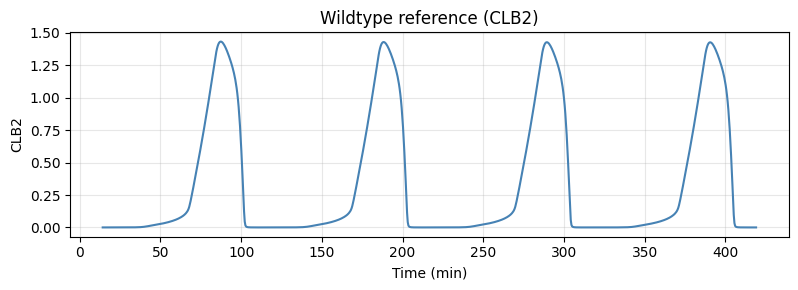

In [50]:
# ── Reference trace ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ref, y_ref, lw=1.5, color="steelblue")
ax.set_title(f"Wildtype reference ({spec.output})")
ax.set_xlabel("Time (min)")
ax.set_ylabel(spec.output)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_reference_trace.png", dpi=150)
plt.show()

In [ ]:
# ── Run NNSE ──────────────────────────────────────────────────────────────────
if LOAD:
    print("LOAD=True — skipping simulation. Set LOAD=False to run.")
else:
    PRINT_INTERVAL = max(1, MAX_STEPS // 100)

    rng = np.random.default_rng(SEED)
    xs, fs = fill_initial_population(objective, p0, bin_thresholds, rng, k_initial=1)

    swap_count        = np.zeros(N_VEC)
    opportunity_count = np.zeros(N_VEC)
    best_history:     list[float]      = []
    neutral_points:   list[np.ndarray] = []
    neutral_values:   list[float]      = []
    neutral_bins:     list[int]        = []   # which bin each neutral point came from
    convergence_step  = None
    remaining_stab    = None
    in_burnin         = False
    start             = time.time()

    # Track last-seen occupant per neutral bin — record on change, from step 1
    _prev = [None] * min(N_NEUTRAL_BIN + 1, N_VEC)

    print(f"{'step':>8}  {'filled':>10}  {'best':>12}  {'neutral':>8}  {'elapsed':>8}")
    print("-" * 55)

    pbar = tqdm(total=MAX_STEPS, desc="NNSE chen2004", unit="step", dynamic_ncols=True)

    for step in range(MAX_STEPS):
        xs, fs, swaps = nnse_step(xs, fs, objective, p0, bin_thresholds, rng, SIGMA)
        finite = [fx for fx in fs if fx is not None and math.isfinite(fx)]
        best   = min(finite) if finite else math.inf
        best_history.append(best)
        filled = sum(x is not None for x in xs)

        if not in_burnin and filled >= MIN_FILLED:
            convergence_step = step
            remaining_stab   = STABILIZATION
            in_burnin        = True
            tqdm.write(f"  *** Convergence at step {step}: {filled}/{N_VEC} filled — "
                       f"running {STABILIZATION} stabilisation steps ***")
        if not in_burnin and step >= BURN_IN_FALLBACK:
            in_burnin = True
            tqdm.write(f"  *** Fallback burn-in triggered at step {step} ***")

        # Swap tracking for volume ratios (only after convergence)
        if in_burnin:
            swap_tuples = set(swaps)
            for i in range(1, N_VEC):
                if fs[i] is not None and fs[i - 1] is not None:
                    opportunity_count[i] += 1
                    if (i, i - 1) in swap_tuples:
                        swap_count[i] += 1

        # Collect all distinct occupants of neutral bins (all steps, on change)
        for i in range(len(_prev)):
            if xs[i] is not None and fs[i] is not None:
                if _prev[i] is None or not np.array_equal(xs[i], _prev[i]):
                    neutral_points.append(xs[i].copy())
                    neutral_values.append(float(fs[i]))
                    neutral_bins.append(i)
                    _prev[i] = xs[i].copy()

        if remaining_stab is not None:
            remaining_stab -= 1
            if remaining_stab <= 0:
                pbar.update(1)
                break

        pbar.update(1)
        pbar.set_postfix(filled=f"{filled}/{N_VEC}", best=f"{best:.2e}", neutral=len(neutral_points))

        if (step + 1) % PRINT_INTERVAL == 0:
            elapsed = time.time() - start
            tqdm.write(f"{step + 1:>8d}  {filled:>4d}/{N_VEC:<5d}  {best:>12.3e}  "
                       f"{len(neutral_points):>8d}  {elapsed:>6.0f}s")

    pbar.close()
    elapsed = time.time() - start
    n_filled = sum(x is not None for x in xs)
    print(f"\nDone in {elapsed:.0f}s | neutral={len(neutral_points)} | filled={n_filled}/{N_VEC}")

In [ ]:
if not LOAD:
    # ── Save result ────────────────────────────────────────────────────────────
    volume_ratios = np.divide(
        swap_count, opportunity_count,
        out=np.full(N_VEC, np.nan),
        where=opportunity_count > 0,
    )
    neutral = (np.array(neutral_points) if neutral_points else np.empty((0, len(p0))))

    stamp   = time.strftime("%Y%m%d_%H%M%S")
    out_npz = RESULT_DIR / f"chen2004_nnse_{stamp}.npz"

    final_x = np.array([x if x is not None else np.full(len(p0), np.nan) for x in xs])
    final_f = np.array([fx if fx is not None else np.nan for fx in fs], dtype=float)

    np.savez_compressed(
        out_npz,
        neutral_points           = neutral,
        neutral_objective_values = np.array(neutral_values, dtype=float),
        neutral_bins             = np.array(neutral_bins, dtype=int),
        final_population         = final_x,
        final_objective_values   = final_f,
        p0                       = p0,
        parameter_names          = np.array(param_names, dtype=object),
        bin_thresholds           = bin_thresholds,
        volume_ratios            = volume_ratios,
        swap_count               = swap_count,
        opportunity_count        = opportunity_count,
        best_history             = np.array(best_history, dtype=float),
        reference_time           = t_ref,
        reference_signal         = y_ref,
    )
    print(f"Saved: {out_npz}")
    print(f"  neutral points: {len(neutral)}  across bins {sorted(set(neutral_bins))}")

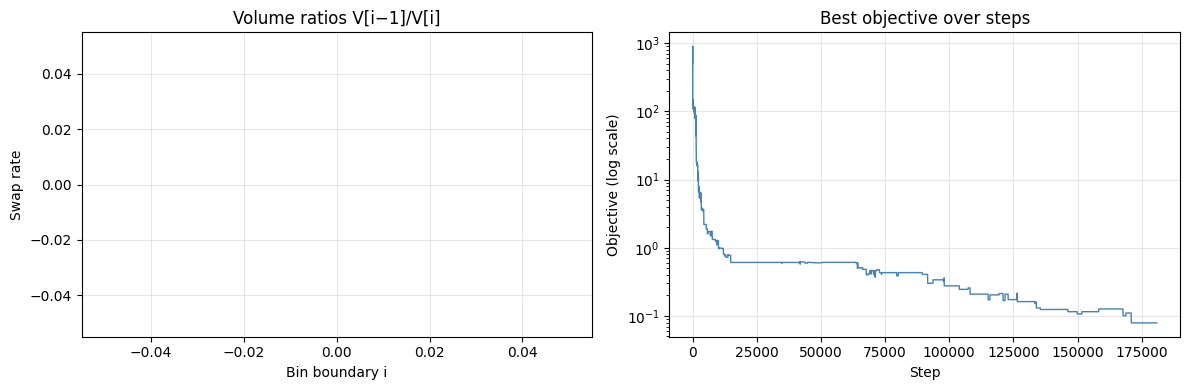

In [53]:
# ── Volume ratios + best objective ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid = ~np.isnan(volume_ratios[1:])
bidx  = np.where(valid)[0] + 1
axes[0].bar(bidx, volume_ratios[1:][valid], color="steelblue", alpha=0.8, width=0.7)
axes[0].set_title("Volume ratios V[i−1]/V[i]")
axes[0].set_xlabel("Bin boundary i")
axes[0].set_ylabel("Swap rate")
axes[0].grid(alpha=0.3)

axes[1].semilogy(best_history, lw=1, color="steelblue")
if convergence_step is not None:
    axes[1].axvline(convergence_step, color="red", ls="--", lw=0.8, label="convergence")
    axes[1].legend()
axes[1].set_title("Best objective over steps")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Objective (log scale)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_nnse_diagnostics.png", dpi=150)
plt.show()

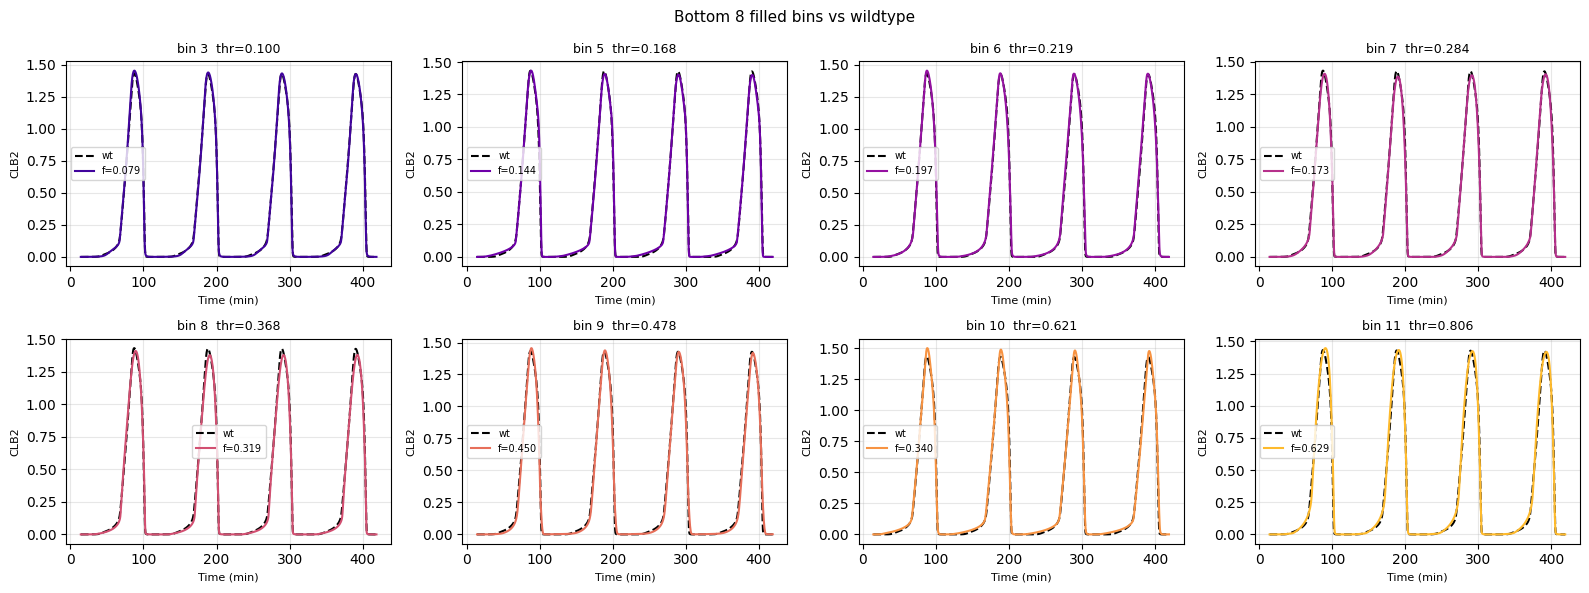

In [55]:
# ── Bottom filled bins: simulated curves vs wildtype ──────────────────────────
from wsbw_nnse import simulate_output, setup_rr as _setup_rr

N_SHOW  = 8
colors  = plt.cm.plasma(np.linspace(0.1, 0.85, N_SHOW))

_item = audit[MODEL_KEY]
_rr, _def, _init = _setup_rr(spec, _item["promoted_sbml"], _item["free_parameters"])

filled_idxs = [i for i in range(len(final_f)) if np.isfinite(final_f[i])][:N_SHOW]

ncols = 4
nrows = math.ceil(len(filled_idxs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = np.array(axes).flatten()

for rank, bidx in enumerate(filled_idxs):
    ax = axes[rank]
    out = simulate_output(_rr, spec, _def, _init, _item["free_parameters"], final_x[bidx])
    ax.plot(t_ref, y_ref, color="black", lw=1.5, ls="--", label="wt")
    if out is not None:
        ax.plot(out[0], out[1], color=colors[rank], lw=1.5, label=f"f={final_f[bidx]:.3f}")
    ax.set_title(f"bin {bidx}  thr={bin_thresholds[bidx]:.3f}", fontsize=9)
    ax.set_xlabel("Time (min)", fontsize=8)
    ax.set_ylabel(spec.output, fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for ax in axes[len(filled_idxs):]:
    ax.set_visible(False)

plt.suptitle(f"Bottom {len(filled_idxs)} filled bins vs wildtype", fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_bottom_bins_curves.png", dpi=150)
plt.show()

In [ ]:
# ── Neutral set analysis ───────────────────────────────────────────────────────
if len(neutral) == 0:
    print(f"No neutral points (bins 0–{N_NEUTRAL_BIN}, f ≤ {bin_thresholds[min(N_NEUTRAL_BIN, N_VEC-1)]:.4f}).")
else:
    ratios = neutral / p0

    # bin assignment for each neutral point
    def _bin_of(f_val):
        for j, t in enumerate(bin_thresholds):
            if f_val <= t:
                return j
        return len(bin_thresholds) - 1

    bin_ids     = np.array([_bin_of(f) for f in neutral_values])
    unique_bins = sorted(set(bin_ids))
    cmap        = plt.cm.plasma(np.linspace(0.1, 0.85, max(len(unique_bins), 1)))
    bin_color   = {b: cmap[i] for i, b in enumerate(unique_bins)}

    # ── Boxplot ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(10, len(param_names) // 2), 4))
    ax.boxplot([ratios[:, i] for i in range(len(param_names))],
               labels=param_names, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", alpha=0.7))
    ax.axhline(1.0, color="red", lw=1.2, ls="--", label="wildtype")
    ax.set_title(f"Neutral set parameter ratios  (n={len(neutral)}, bins 0–{N_NEUTRAL_BIN})")
    ax.set_ylabel("p / p₀")
    ax.tick_params(axis="x", rotation=45, labelsize=6)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "03_neutral_ratios.png", dpi=150)
    plt.show()

    # ── PCA ────────────────────────────────────────────────────────────────────
    if len(neutral) >= 2:
        X_c = ratios - ratios.mean(axis=0)
        _, _, Vt = np.linalg.svd(X_c, full_matrices=False)
        pc1 = X_c @ Vt[0]
        pc2 = X_c @ Vt[1] if Vt.shape[0] > 1 else np.zeros(len(X_c))

        fig, ax = plt.subplots(figsize=(6, 5))
        for b in unique_bins:
            m = bin_ids == b
            ax.scatter(pc1[m], pc2[m], color=bin_color[b], s=80,
                       edgecolors="k", linewidths=0.5, zorder=3,
                       label=f"bin {b}  f≤{bin_thresholds[b]:.3f}")
        ax.axhline(0, color="grey", lw=0.5)
        ax.axvline(0, color="grey", lw=0.5)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title(f"PCA of neutral set  (n={len(neutral)}, fold-change space)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(PLOT_DIR / "05_neutral_pca.png", dpi=150)
        plt.show()
    else:
        print("Only 1 neutral point — PCA needs ≥ 2. Run more steps to collect more.")

    print(f"Neutral set size: {len(neutral)}")
    print(f"Median |log2 fold-change|: {float(np.median(np.abs(np.log2(ratios)))):.3f}")